# 05. Model Evaluation

В этом ноутбуке сравниваем модели, обученные ранее:

- WOE Logistic Regression / Scorecard из `03_woe_iv_scorecard.ipynb`;
- LightGBM из `04_train_lightgbm.ipynb`.

Основные задачи:

1. Загрузить сохранённые модели, метрики и предсказания.
2. Сравнить качество моделей по ROC-AUC и PR-AUC.
3. Проанализировать threshold policy.
4. Построить KS-curve.
5. Проверить calibration вероятностей.
6. Подготовить финальные артефакты для отчёта и inference.

In [1]:
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

PROJECT_ROOT: /Users/artem/PycharmProjects/credit-risk-scoring-service
PROCESSED_DIR: /Users/artem/PycharmProjects/credit-risk-scoring-service/data/processed
MODELS_DIR: /Users/artem/PycharmProjects/credit-risk-scoring-service/models
FIGURES_DIR: /Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures


## 1. Загрузка данных и артефактов

Для честного сравнения моделей восстановим тот же train/validation split, который использовался в ноутбуках `03` и `04`.

Также загрузим сохранённые метрики и модели из папки `models/`.

In [3]:
train_path = PROCESSED_DIR / "train_features.parquet"
test_path = PROCESSED_DIR / "test_features.parquet"

train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)

TARGET = "TARGET"
ID_COL = "SK_ID_CURR"

feature_cols = [
    col for col in train.columns
    if col not in [TARGET, ID_COL]
]

X = train[feature_cols].copy()
y = train[TARGET].copy()

test_ids = test[ID_COL].copy()
X_test = test[feature_cols].copy()

print("train:", train.shape)
print("test:", test.shape)
print("X:", X.shape)
print("X_test:", X_test.shape)
print("Target mean:", y.mean())

train: (307511, 324)
test: (48744, 323)
X: (307511, 322)
X_test: (48744, 322)
Target mean: 0.08072881945686496


In [4]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_valid = X_valid.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test:", X_test.shape)

print("y_train mean:", y_train.mean())
print("y_valid mean:", y_valid.mean())

X_train: (246008, 322)
X_valid: (61503, 322)
X_test: (48744, 322)
y_train mean: 0.08072908198107379
y_valid mean: 0.08072776937710356


In [5]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


scorecard_metrics_path = MODELS_DIR / "scorecard_metrics.json"
lightgbm_metrics_path = MODELS_DIR / "lightgbm_metrics.json"

scorecard_metrics = load_json(scorecard_metrics_path)
lightgbm_metrics = load_json(lightgbm_metrics_path)

scorecard_metrics, lightgbm_metrics

({'model': 'woe_logistic_regression',
  'n_features': 122,
  'train_roc_auc': 0.7662909437644956,
  'valid_roc_auc': 0.7683222366961743,
  'train_pr_auc': 0.24794113520504205,
  'valid_pr_auc': 0.25488715238599746,
  'threshold': 0.7000000000000002,
  'valid_predicted_bad_rate': 0.11766905679397753,
  'valid_approval_rate': 0.8823309432060225,
  'valid_precision_bad': 0.2655796600801437,
  'valid_recall_bad': 0.3871097683786506,
  'valid_f1_bad': 0.3150303228978856},
 {'model': 'lightgbm',
  'best_iteration': 770,
  'n_features': 322,
  'n_categorical_features': 16,
  'n_numeric_features': 306,
  'train_roc_auc': 0.881491923646647,
  'valid_roc_auc': 0.7883975154960883,
  'train_pr_auc': 0.40962482529541816,
  'valid_pr_auc': 0.2866316232885762})

In [6]:
metrics_comparison = pd.DataFrame(
    [
        {
            "model": "WOE Logistic Regression",
            "valid_roc_auc": scorecard_metrics["valid_roc_auc"],
            "valid_pr_auc": scorecard_metrics["valid_pr_auc"],
            "threshold": scorecard_metrics["threshold"],
            "approval_rate": scorecard_metrics["valid_approval_rate"],
            "recall_bad": scorecard_metrics["valid_recall_bad"],
            "precision_bad": scorecard_metrics["valid_precision_bad"],
            "f1_bad": scorecard_metrics["valid_f1_bad"],
        },
        {
            "model": "LightGBM",
            "valid_roc_auc": lightgbm_metrics["valid_roc_auc"],
            "valid_pr_auc": lightgbm_metrics["valid_pr_auc"],
            "threshold": np.nan,
            "approval_rate": np.nan,
            "recall_bad": np.nan,
            "precision_bad": np.nan,
            "f1_bad": np.nan,
        },
    ]
)

metrics_comparison

,model,valid_roc_auc,valid_pr_auc,threshold,approval_rate,recall_bad,precision_bad,f1_bad
0,WOE Logistic Regression,0.768322,0.254887,0.7,0.882331,0.38711,0.26558,0.31503
1,LightGBM,0.788398,0.286632,NaN,NaN,NaN,NaN,NaN


## 2. Восстановление validation predictions

Теперь загрузим сохранённые модели и восстановим предсказания на той же validation-выборке.

Для scorecard-модели нужно:

1. загрузить WOE-transformer;
2. преобразовать `X_valid` в WOE-признаки;
3. применить логистическую регрессию.

Для LightGBM достаточно применить модель к исходным признакам.

In [7]:
scorecard_model_path = MODELS_DIR / "scorecard_logreg_model.pkl"
woe_transformer_path = MODELS_DIR / "scorecard_woe_transformer.pkl"
lightgbm_model_path = MODELS_DIR / "lightgbm_model.pkl"

with open(scorecard_model_path, "rb") as f:
    scorecard_model = pickle.load(f)

with open(woe_transformer_path, "rb") as f:
    woe_transformer = pickle.load(f)

with open(lightgbm_model_path, "rb") as f:
    lightgbm_model = pickle.load(f)

print("Models loaded")

Models loaded


In [8]:
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.scoring.woe import apply_woe_transformer

print("WOE transformer imported")

WOE transformer imported


In [9]:
X_valid_woe = apply_woe_transformer(X_valid, woe_transformer)

scorecard_valid_proba = scorecard_model.predict_proba(X_valid_woe)[:, 1]

scorecard_valid_auc = roc_auc_score(y_valid, scorecard_valid_proba)
scorecard_valid_pr_auc = average_precision_score(y_valid, scorecard_valid_proba)

print("Scorecard ROC-AUC:", round(scorecard_valid_auc, 4))
print("Scorecard PR-AUC:", round(scorecard_valid_pr_auc, 4))
print("X_valid_woe:", X_valid_woe.shape)

Scorecard ROC-AUC: 0.7683
Scorecard PR-AUC: 0.2549
X_valid_woe: (61503, 122)


In [11]:
# Загружаем список признаков, на которых обучался LightGBM
lightgbm_feature_list_path = MODELS_DIR / "lightgbm_feature_list.json"

with open(lightgbm_feature_list_path, "r", encoding="utf-8") as f:
    lightgbm_feature_cols = json.load(f)

print("LightGBM feature count:", len(lightgbm_feature_cols))
print("Current X_valid feature count:", X_valid.shape[1])

# Приводим validation/test к тому же набору и порядку колонок
X_valid_lgb = X_valid[lightgbm_feature_cols].copy()
X_test_lgb = X_test[lightgbm_feature_cols].copy()

# Восстанавливаем категориальные признаки так же, как в 04 ноутбуке
categorical_features = X_valid_lgb.select_dtypes(
    exclude=["number", "bool"]
).columns.tolist()

for col in categorical_features:
    X_valid_lgb[col] = X_valid_lgb[col].astype("category")
    X_test_lgb[col] = X_test_lgb[col].astype("category")

print("X_valid_lgb:", X_valid_lgb.shape)
print("Categorical features:", len(categorical_features))

LightGBM feature count: 322
Current X_valid feature count: 322
X_valid_lgb: (61503, 322)
Categorical features: 16


In [12]:
lightgbm_valid_proba = lightgbm_model.predict(
    X_valid_lgb,
    num_iteration=lightgbm_model.best_iteration,
    validate_features=False
)

lightgbm_valid_auc = roc_auc_score(y_valid, lightgbm_valid_proba)
lightgbm_valid_pr_auc = average_precision_score(y_valid, lightgbm_valid_proba)

print("LightGBM ROC-AUC:", round(lightgbm_valid_auc, 4))
print("LightGBM PR-AUC:", round(lightgbm_valid_pr_auc, 4))

LightGBM ROC-AUC: 0.7884
LightGBM PR-AUC: 0.2866


## 3. ROC и Precision-Recall сравнение

Построим ROC и Precision-Recall кривые для двух моделей на одной validation-выборке.

Это позволяет визуально сравнить:

- насколько хорошо модели ранжируют клиентов по риску;
- какая модель лучше работает с редким bad-классом.

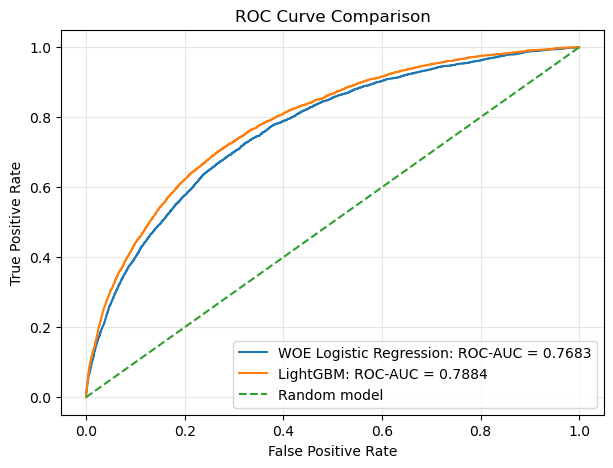

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures/model_comparison_roc_curve.png


In [13]:
plt.figure(figsize=(7, 5))

for model_name, y_proba, auc_value in [
    ("WOE Logistic Regression", scorecard_valid_proba, scorecard_valid_auc),
    ("LightGBM", lightgbm_valid_proba, lightgbm_valid_auc),
]:
    fpr, tpr, _ = roc_curve(y_valid, y_proba)
    plt.plot(fpr, tpr, label=f"{model_name}: ROC-AUC = {auc_value:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

roc_comparison_path = FIGURES_DIR / "model_comparison_roc_curve.png"
plt.savefig(roc_comparison_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", roc_comparison_path)

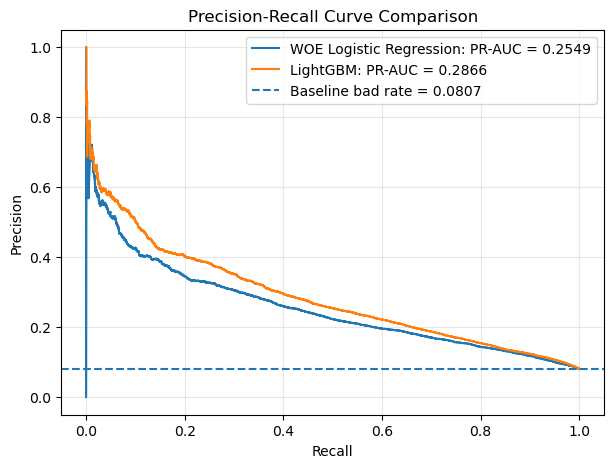

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures/model_comparison_pr_curve.png


In [14]:
plt.figure(figsize=(7, 5))

for model_name, y_proba, pr_auc_value in [
    ("WOE Logistic Regression", scorecard_valid_proba, scorecard_valid_pr_auc),
    ("LightGBM", lightgbm_valid_proba, lightgbm_valid_pr_auc),
]:
    precision, recall, _ = precision_recall_curve(y_valid, y_proba)
    plt.plot(recall, precision, label=f"{model_name}: PR-AUC = {pr_auc_value:.4f}")

baseline_bad_rate = y_valid.mean()
plt.axhline(
    baseline_bad_rate,
    linestyle="--",
    label=f"Baseline bad rate = {baseline_bad_rate:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

pr_comparison_path = FIGURES_DIR / "model_comparison_pr_curve.png"
plt.savefig(pr_comparison_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", pr_comparison_path)

## 4. KS metric

KS — одна из классических метрик кредитного скоринга.

Она показывает максимальное расстояние между накопленным распределением bad-клиентов и good-клиентов при сортировке клиентов по предсказанному риску.

Чем выше KS, тем лучше модель разделяет хорошие и плохие заявки.

In [15]:
def calculate_ks_table(y_true, y_proba, n_bins=10):
    ks_df = pd.DataFrame({
        "target": y_true.values if hasattr(y_true, "values") else y_true,
        "proba": y_proba
    })

    ks_df["bucket"] = pd.qcut(
        ks_df["proba"],
        q=n_bins,
        duplicates="drop"
    )

    ks_table = (
        ks_df
        .groupby("bucket", observed=True)
        .agg(
            total=("target", "count"),
            bad=("target", "sum"),
            min_proba=("proba", "min"),
            max_proba=("proba", "max"),
            avg_proba=("proba", "mean"),
        )
        .reset_index()
        .sort_values("avg_proba", ascending=False)
        .reset_index(drop=True)
    )

    ks_table["good"] = ks_table["total"] - ks_table["bad"]
    ks_table["bad_rate"] = ks_table["bad"] / ks_table["total"]

    ks_table["cum_bad"] = ks_table["bad"].cumsum() / ks_table["bad"].sum()
    ks_table["cum_good"] = ks_table["good"].cumsum() / ks_table["good"].sum()

    ks_table["ks"] = np.abs(ks_table["cum_bad"] - ks_table["cum_good"])

    return ks_table

In [16]:
scorecard_ks_table = calculate_ks_table(
    y_valid,
    scorecard_valid_proba,
    n_bins=10
)

lightgbm_ks_table = calculate_ks_table(
    y_valid,
    lightgbm_valid_proba,
    n_bins=10
)

scorecard_ks = scorecard_ks_table["ks"].max()
lightgbm_ks = lightgbm_ks_table["ks"].max()

print("Scorecard KS:", round(scorecard_ks, 4))
print("LightGBM KS:", round(lightgbm_ks, 4))

lightgbm_ks_table

Scorecard KS: 0.4006
LightGBM KS: 0.4337


,bucket,total,bad,min_proba,max_proba,avg_proba,good,bad_rate,cum_bad,cum_good,ks
0,"(0.702, 0.951]",6151,1873.0,0.701677,0.951254,0.787133,4278.0,0.304503,0.377241,0.075666,0.301575
1,"(0.579, 0.702]",6150,972.0,0.578508,0.701665,0.638438,5178.0,0.158049,0.573011,0.167250,0.405761
2,"(0.473, 0.579]",6150,624.0,0.473200,0.578507,0.524853,5526.0,0.101463,0.698691,0.264990,0.433701
3,"(0.384, 0.473]",6150,440.0,0.384015,0.473181,0.427344,5710.0,0.071545,0.787311,0.365984,0.421327
4,"(0.308, 0.384]",6150,312.0,0.307806,0.384014,0.344666,5838.0,0.050732,0.850151,0.469242,0.380909
5,"(0.243, 0.308]",6151,281.0,0.243387,0.307784,0.274751,5870.0,0.045684,0.906747,0.573066,0.333681
6,"(0.187, 0.243]",6150,192.0,0.186633,0.243380,0.214587,5958.0,0.031220,0.945418,0.678446,0.266972
7,"(0.136, 0.187]",6150,132.0,0.135923,0.186628,0.160476,6018.0,0.021463,0.972004,0.784888,0.187116
8,"(0.0871, 0.136]",6150,87.0,0.087121,0.135920,0.111498,6063.0,0.014146,0.989527,0.892126,0.097401
9,"(0.0033699999999999997, 0.0871]",6151,52.0,0.004365,0.087092,0.057877,6099.0,0.008454,1.000000,1.000000,0.000000


In [17]:
ks_comparison = pd.DataFrame([
    {
        "model": "WOE Logistic Regression",
        "ks": scorecard_ks
    },
    {
        "model": "LightGBM",
        "ks": lightgbm_ks
    },
]).sort_values("ks", ascending=False)

ks_comparison

,model,ks
1,LightGBM,0.433701
0,WOE Logistic Regression,0.400617


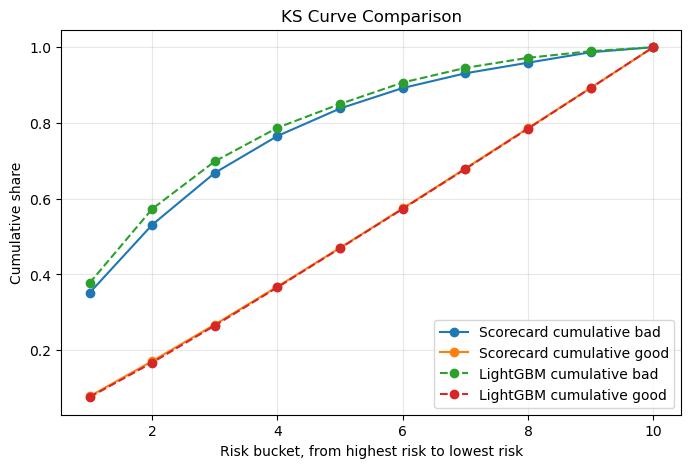

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures/model_comparison_ks_curve.png


In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    scorecard_ks_table.index + 1,
    scorecard_ks_table["cum_bad"],
    marker="o",
    label="Scorecard cumulative bad"
)
plt.plot(
    scorecard_ks_table.index + 1,
    scorecard_ks_table["cum_good"],
    marker="o",
    label="Scorecard cumulative good"
)

plt.plot(
    lightgbm_ks_table.index + 1,
    lightgbm_ks_table["cum_bad"],
    marker="o",
    linestyle="--",
    label="LightGBM cumulative bad"
)
plt.plot(
    lightgbm_ks_table.index + 1,
    lightgbm_ks_table["cum_good"],
    marker="o",
    linestyle="--",
    label="LightGBM cumulative good"
)

plt.xlabel("Risk bucket, from highest risk to lowest risk")
plt.ylabel("Cumulative share")
plt.title("KS Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

ks_curve_path = FIGURES_DIR / "model_comparison_ks_curve.png"
plt.savefig(ks_curve_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", ks_curve_path)

## 5. Calibration check

ROC-AUC и PR-AUC оценивают качество ранжирования, но не проверяют, насколько хорошо предсказания модели соответствуют реальным вероятностям дефолта.

Calibration показывает, насколько близки predicted probabilities к фактическому default rate.

Это особенно важно для LightGBM, потому что модель обучалась с `scale_pos_weight`, из-за чего вероятности могут быть смещены.

In [19]:
def create_calibration_table(y_true, y_proba, n_bins=10):
    calibration_df = pd.DataFrame({
        "target": y_true.values if hasattr(y_true, "values") else y_true,
        "proba": y_proba
    })

    calibration_df["bucket"] = pd.qcut(
        calibration_df["proba"],
        q=n_bins,
        duplicates="drop"
    )

    calibration_table = (
        calibration_df
        .groupby("bucket", observed=True)
        .agg(
            total=("target", "count"),
            bad=("target", "sum"),
            avg_predicted_pd=("proba", "mean"),
        )
        .reset_index()
        .sort_values("avg_predicted_pd", ascending=True)
        .reset_index(drop=True)
    )

    calibration_table["actual_bad_rate"] = (
        calibration_table["bad"] / calibration_table["total"]
    )

    return calibration_table

In [20]:
scorecard_calibration = create_calibration_table(
    y_valid,
    scorecard_valid_proba,
    n_bins=10
)

lightgbm_calibration = create_calibration_table(
    y_valid,
    lightgbm_valid_proba,
    n_bins=10
)

print("Scorecard calibration:")
display(scorecard_calibration)

print("LightGBM calibration:")
display(lightgbm_calibration)

Scorecard calibration:


,bucket,total,bad,avg_predicted_pd,actual_bad_rate
0,"(-0.0009734, 0.149]",6151,66.0,0.109257,0.010730
1,"(0.149, 0.207]",6150,137.0,0.178379,0.022276
2,"(0.207, 0.263]",6150,139.0,0.234975,0.022602
3,"(0.263, 0.321]",6150,193.0,0.291297,0.031382
4,"(0.321, 0.38]",6151,268.0,0.350188,0.043570
5,"(0.38, 0.448]",6150,361.0,0.413226,0.058699
6,"(0.448, 0.524]",6150,483.0,0.485287,0.078537
7,"(0.524, 0.612]",6150,681.0,0.566694,0.110732
8,"(0.612, 0.722]",6150,893.0,0.664273,0.145203
9,"(0.722, 0.962]",6151,1744.0,0.802176,0.283531


LightGBM calibration:


,bucket,total,bad,avg_predicted_pd,actual_bad_rate
0,"(0.0033699999999999997, 0.0871]",6151,52.0,0.057877,0.008454
1,"(0.0871, 0.136]",6150,87.0,0.111498,0.014146
2,"(0.136, 0.187]",6150,132.0,0.160476,0.021463
3,"(0.187, 0.243]",6150,192.0,0.214587,0.031220
4,"(0.243, 0.308]",6151,281.0,0.274751,0.045684
5,"(0.308, 0.384]",6150,312.0,0.344666,0.050732
6,"(0.384, 0.473]",6150,440.0,0.427344,0.071545
7,"(0.473, 0.579]",6150,624.0,0.524853,0.101463
8,"(0.579, 0.702]",6150,972.0,0.638438,0.158049
9,"(0.702, 0.951]",6151,1873.0,0.787133,0.304503


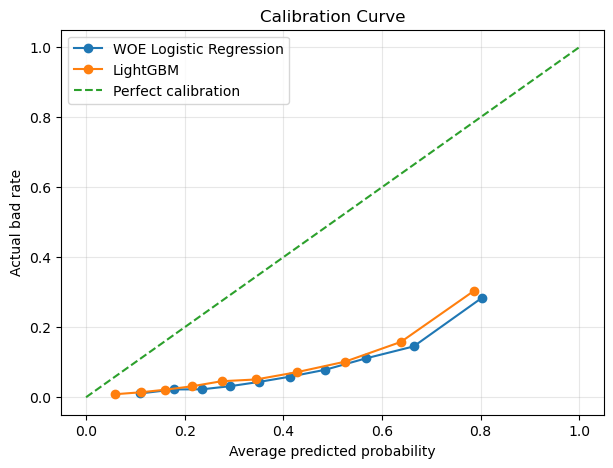

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures/model_comparison_calibration_curve.png


In [21]:
plt.figure(figsize=(7, 5))

for model_name, calibration_table in [
    ("WOE Logistic Regression", scorecard_calibration),
    ("LightGBM", lightgbm_calibration),
]:
    plt.plot(
        calibration_table["avg_predicted_pd"],
        calibration_table["actual_bad_rate"],
        marker="o",
        label=model_name
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.xlabel("Average predicted probability")
plt.ylabel("Actual bad rate")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)

calibration_path = FIGURES_DIR / "model_comparison_calibration_curve.png"
plt.savefig(calibration_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", calibration_path)

In [22]:
calibration_metrics = pd.DataFrame([
    {
        "model": "WOE Logistic Regression",
        "brier_score": brier_score_loss(y_valid, scorecard_valid_proba),
    },
    {
        "model": "LightGBM",
        "brier_score": brier_score_loss(y_valid, lightgbm_valid_proba),
    },
]).sort_values("brier_score")

calibration_metrics

,model,brier_score
1,LightGBM,0.163457
0,WOE Logistic Regression,0.195426


## 6. Threshold analysis for LightGBM

LightGBM показывает лучшее ранжирование, но для бизнес-решения нужно выбрать threshold.

Threshold переводит вероятность дефолта в бинарное решение:

- `proba >= threshold` → bad / reject / manual review;
- `proba < threshold` → good / approve.

Так как классы несбалансированы, threshold `0.5` не обязательно оптимален.

In [23]:
thresholds = np.arange(0.1, 0.9, 0.05)

lightgbm_threshold_rows = []

for threshold in thresholds:
    y_pred = (lightgbm_valid_proba >= threshold).astype(int)

    lightgbm_threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_valid, y_pred, zero_division=0),
        "recall": recall_score(y_valid, y_pred, zero_division=0),
        "f1": f1_score(y_valid, y_pred, zero_division=0),
        "approval_rate": 1 - y_pred.mean(),
        "predicted_bad_rate": y_pred.mean(),
    })

lightgbm_threshold_df = pd.DataFrame(lightgbm_threshold_rows)

lightgbm_threshold_df.sort_values("f1", ascending=False).head(10)

,threshold,precision,recall,f1,approval_rate,predicted_bad_rate
11,0.65,0.266713,0.462840,0.338414,0.859909,0.140091
12,0.70,0.303915,0.381470,0.338305,0.898672,0.101328
10,0.60,0.241639,0.542800,0.334409,0.818659,0.181341
9,0.55,0.218323,0.611480,0.321764,0.773897,0.226103
13,0.75,0.353540,0.293656,0.320827,0.932946,0.067054
8,0.50,0.197429,0.668077,0.304787,0.726826,0.273174
7,0.45,0.179862,0.722054,0.287987,0.675918,0.324082
6,0.40,0.163587,0.772205,0.269981,0.618929,0.381071
14,0.80,0.408000,0.195166,0.264033,0.961384,0.038616
5,0.35,0.149239,0.817523,0.252402,0.557778,0.442222


In [24]:
lightgbm_best_threshold = lightgbm_threshold_df.loc[
    lightgbm_threshold_df["f1"].idxmax(),
    "threshold"
]

lightgbm_best_threshold

np.float64(0.6500000000000001)

In [25]:
lightgbm_valid_pred = (
    lightgbm_valid_proba >= lightgbm_best_threshold
).astype(int)

lightgbm_cm = confusion_matrix(y_valid, lightgbm_valid_pred)

lightgbm_cm_df = pd.DataFrame(
    lightgbm_cm,
    index=["Actual good (0)", "Actual bad (1)"],
    columns=["Predicted good (0)", "Predicted bad (1)"]
)

lightgbm_cm_df

,Predicted good (0),Predicted bad (1)
Actual good (0),50220,6318
Actual bad (1),2667,2298


In [26]:
lightgbm_cm_normalized = lightgbm_cm_df.div(
    lightgbm_cm_df.sum(axis=1),
    axis=0
)

lightgbm_cm_normalized

,Predicted good (0),Predicted bad (1)
Actual good (0),0.888252,0.111748
Actual bad (1),0.537160,0.462840


In [27]:
print("LightGBM threshold:", lightgbm_best_threshold)

print(classification_report(
    y_valid,
    lightgbm_valid_pred,
    target_names=["good_0", "bad_1"]
))

LightGBM threshold: 0.6500000000000001
              precision    recall  f1-score   support

      good_0       0.95      0.89      0.92     56538
       bad_1       0.27      0.46      0.34      4965

    accuracy                           0.85     61503
   macro avg       0.61      0.68      0.63     61503
weighted avg       0.89      0.85      0.87     61503



## 7. Threshold policy comparison

Сравним scorecard и LightGBM при выбранных threshold.

Для scorecard используем threshold из ноутбука `03`, выбранный по F1.  
Для LightGBM используем threshold, выбранный по F1 на validation в этом ноутбуке.

In [28]:
scorecard_threshold = float(scorecard_metrics["threshold"])

scorecard_valid_pred = (
    scorecard_valid_proba >= scorecard_threshold
).astype(int)

threshold_policy_comparison = pd.DataFrame([
    {
        "model": "WOE Logistic Regression",
        "threshold": scorecard_threshold,
        "precision_bad": precision_score(y_valid, scorecard_valid_pred, zero_division=0),
        "recall_bad": recall_score(y_valid, scorecard_valid_pred, zero_division=0),
        "f1_bad": f1_score(y_valid, scorecard_valid_pred, zero_division=0),
        "approval_rate": 1 - scorecard_valid_pred.mean(),
        "predicted_bad_rate": scorecard_valid_pred.mean(),
    },
    {
        "model": "LightGBM",
        "threshold": float(lightgbm_best_threshold),
        "precision_bad": precision_score(y_valid, lightgbm_valid_pred, zero_division=0),
        "recall_bad": recall_score(y_valid, lightgbm_valid_pred, zero_division=0),
        "f1_bad": f1_score(y_valid, lightgbm_valid_pred, zero_division=0),
        "approval_rate": 1 - lightgbm_valid_pred.mean(),
        "predicted_bad_rate": lightgbm_valid_pred.mean(),
    },
])

threshold_policy_comparison

,model,threshold,precision_bad,recall_bad,f1_bad,approval_rate,predicted_bad_rate
0,WOE Logistic Regression,0.70,0.265580,0.38711,0.315030,0.882331,0.117669
1,LightGBM,0.65,0.266713,0.46284,0.338414,0.859909,0.140091


In [29]:
threshold_policy_path = MODELS_DIR / "model_threshold_policy_comparison.csv"

threshold_policy_comparison.to_csv(threshold_policy_path, index=False)

print("Saved:", threshold_policy_path)

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/model_threshold_policy_comparison.csv


In [30]:
evaluation_summary = metrics_comparison.copy()

evaluation_summary = evaluation_summary.drop(
    columns=["threshold", "approval_rate", "recall_bad", "precision_bad", "f1_bad"],
    errors="ignore"
)

evaluation_summary = evaluation_summary.merge(
    ks_comparison,
    on="model",
    how="left"
)

evaluation_summary = evaluation_summary.merge(
    calibration_metrics,
    on="model",
    how="left"
)

evaluation_summary = evaluation_summary.merge(
    threshold_policy_comparison,
    on="model",
    how="left"
)

evaluation_summary = evaluation_summary.sort_values(
    "valid_roc_auc",
    ascending=False
).reset_index(drop=True)

evaluation_summary

,model,valid_roc_auc,valid_pr_auc,ks,brier_score,threshold,precision_bad,recall_bad,f1_bad,approval_rate,predicted_bad_rate
0,LightGBM,0.788398,0.286632,0.433701,0.163457,0.65,0.266713,0.46284,0.338414,0.859909,0.140091
1,WOE Logistic Regression,0.768322,0.254887,0.400617,0.195426,0.70,0.265580,0.38711,0.315030,0.882331,0.117669


In [31]:
evaluation_summary_path = MODELS_DIR / "model_evaluation_summary.csv"

evaluation_summary.to_csv(evaluation_summary_path, index=False)

print("Saved:", evaluation_summary_path)

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/model_evaluation_summary.csv


In [32]:
final_model_config = {
    "selected_model": "LightGBM",
    "reason": "Best validation ROC-AUC, PR-AUC, KS and Brier score among evaluated models.",
    "valid_roc_auc": float(lightgbm_valid_auc),
    "valid_pr_auc": float(lightgbm_valid_pr_auc),
    "ks": float(lightgbm_ks),
    "brier_score": float(
        calibration_metrics.loc[
            calibration_metrics["model"] == "LightGBM",
            "brier_score"
        ].iloc[0]
    ),
    "threshold": float(lightgbm_best_threshold),
    "threshold_selection_method": "max_f1_on_validation",
}

final_model_config_path = MODELS_DIR / "final_model_config.json"

with open(final_model_config_path, "w", encoding="utf-8") as f:
    json.dump(final_model_config, f, ensure_ascii=False, indent=2)

final_model_config

{'selected_model': 'LightGBM',
 'reason': 'Best validation ROC-AUC, PR-AUC, KS and Brier score among evaluated models.',
 'valid_roc_auc': 0.7883975154960883,
 'valid_pr_auc': 0.2866316232885762,
 'ks': 0.4337009175659095,
 'brier_score': 0.1634571567710164,
 'threshold': 0.6500000000000001,
 'threshold_selection_method': 'max_f1_on_validation'}

## 8. Выводы

В этом ноутбуке были сравнены две основные модели проекта:

- WOE Logistic Regression / Scorecard;
- LightGBM.

По итогам evaluation LightGBM показал лучшее качество:

- выше ROC-AUC;
- выше PR-AUC;
- выше KS;
- ниже Brier score.

Scorecard-модель остаётся полезной как интерпретируемый baseline и пример классического кредитного скоринга.  
LightGBM выбирается как основная ML-модель для дальнейшего inference pipeline.

Важно: обе модели завышают predicted probabilities относительно фактического default rate. Поэтому перед использованием предсказаний как реальной PD нужна дополнительная calibration. Для ранжирования клиентов по риску LightGBM уже показывает лучшее качество.

In [33]:
saved_files = [
    MODELS_DIR / "model_threshold_policy_comparison.csv",
    MODELS_DIR / "model_evaluation_summary.csv",
    MODELS_DIR / "final_model_config.json",
    FIGURES_DIR / "model_comparison_roc_curve.png",
    FIGURES_DIR / "model_comparison_pr_curve.png",
    FIGURES_DIR / "model_comparison_ks_curve.png",
    FIGURES_DIR / "model_comparison_calibration_curve.png",
]

for path in saved_files:
    print(path, "->", path.exists())

/Users/artem/PycharmProjects/credit-risk-scoring-service/models/model_threshold_policy_comparison.csv -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/models/model_evaluation_summary.csv -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/models/final_model_config.json -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures/model_comparison_roc_curve.png -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures/model_comparison_pr_curve.png -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures/model_comparison_ks_curve.png -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures/model_comparison_calibration_curve.png -> True
